<a href="https://colab.research.google.com/github/umang0015/Ai-DataScience/blob/main/clustering_analysis_eda_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GitHub AI Repositories — Clustering Analysis

**Objective:** Group GitHub AI repositories into meaningful clusters based on their popularity and activity metrics, using unsupervised machine learning (K-Means, DBSCAN, and Agglomerative Clustering).

**Dataset:** `github_ai_repos_2026.csv` — contains information about 2,853 AI-related GitHub repositories, including stars, forks, watchers, open issues, repository size, contributors, and recent commit activity.

**Workflow followed in this notebook:**
1. Load and inspect the dataset
2. Perform a focused Exploratory Data Analysis (EDA) — just enough to justify feature choices
3. Select and preprocess features suitable for clustering
4. Scale the features
5. Find the optimal number of clusters
6. Apply K-Means, DBSCAN, and Agglomerative Clustering (the main focus of this notebook)
7. Evaluate and compare all three models in depth
8. Interpret the resulting clusters
9. Draw conclusions based on the actual results

**Note:** EDA in this notebook is kept concise and only covers what's needed to justify preprocessing and feature-selection decisions. The main depth of this project is in the clustering, evaluation, and interpretation sections.


## 1. Import Libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering algorithms
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Evaluation metrics
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

# Dimensionality reduction (for visualization)
from sklearn.decomposition import PCA

# Hierarchical clustering (for dendrogram)
from scipy.cluster.hierarchy import dendrogram, linkage

# Plot settings
sns.set_style("whitegrid")
%matplotlib inline

## 2. Load Dataset

In [ ]:
# Load the dataset
df = pd.read_csv("github_ai_repos_2026.csv")
df.head()

,full_name,name,owner,description,stars,forks,watchers,open_issues,language,license,...,size_kb,default_branch,is_fork,archived,has_wiki,has_pages,contributors,commits_last_4w,commits_last_52w,html_url
0,tensorflow/tensorflow,tensorflow,tensorflow,An Open Source Machine Learning Framework for ...,194766,75283,194766,4455,C++,Apache-2.0,...,1307558,master,False,False,False,False,5053.0,1039.0,13310.0,https://github.com/tensorflow/tensorflow
1,Significant-Gravitas/AutoGPT,AutoGPT,Significant-Gravitas,AutoGPT is the vision of accessible AI for eve...,183489,46223,183489,382,Python,NOASSERTION,...,510366,master,False,False,True,False,812.0,NaN,NaN,https://github.com/Significant-Gravitas/AutoGPT
2,ollama/ollama,ollama,ollama,"Get up and running with Kimi-K2.5, GLM-5, Mini...",169211,15631,169211,2959,Go,MIT,...,78924,main,False,False,False,False,597.0,NaN,NaN,https://github.com/ollama/ollama
3,f/prompts.chat,prompts.chat,f,"f.k.a. Awesome ChatGPT Prompts. Share, discove...",159897,20939,159897,43,HTML,NOASSERTION,...,312378,main,False,False,True,True,963.0,NaN,NaN,https://github.com/f/prompts.chat
4,huggingface/transformers,transformers,huggingface,🤗 Transformers: the model-definition framework...,159495,32895,159495,2352,Python,Apache-2.0,...,466632,main,False,False,True,False,3878.0,318.0,5212.0,https://github.com/huggingface/transformers


## 3. Dataset Overview

In [ ]:
# Shape, data types, and descriptive statistics together
print("Shape:", df.shape)
df.dtypes

Shape: (2853, 24)


full_name               str
name                    str
owner                   str
description             str
stars                 int64
forks                 int64
watchers              int64
open_issues           int64
language                str
license                 str
topics                  str
created_at              str
updated_at              str
pushed_at               str
size_kb               int64
default_branch          str
is_fork                bool
archived               bool
has_wiki               bool
has_pages              bool
contributors        float64
commits_last_4w     float64
commits_last_52w    float64
html_url                str
dtype: object

In [ ]:
# Descriptive statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
stars,2853.0,6728.892744,15605.033438,52.0,439.0,1280.0,5911.00,194766.0
forks,2853.0,1127.130039,3444.936824,0.0,61.0,198.0,867.00,75283.0
watchers,2853.0,6728.892744,15605.033438,52.0,439.0,1280.0,5911.00,194766.0
open_issues,2853.0,96.534876,315.402009,0.0,3.0,15.0,59.00,5057.0
size_kb,2853.0,106105.008412,348679.635365,4.0,2151.0,15889.0,75360.00,6595212.0
contributors,500.0,227.254000,502.235605,1.0,22.0,72.0,245.25,5053.0
commits_last_4w,39.0,448.666667,508.532581,0.0,97.5,283.0,721.50,2506.0
commits_last_52w,39.0,5991.666667,6148.773816,0.0,1587.5,4346.0,8682.50,30528.0


## 4. Data Quality Check

In [ ]:
# Missing values (count + percentage) and duplicate rows
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print("Missing values (%):")
print(missing_percent)
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values (%):
commits_last_52w    98.63
commits_last_4w     98.63
contributors        82.47
topics              28.64
license             19.98
language            12.30
description          1.02
dtype: float64

Duplicate rows: 0


**Observation:** `contributors`, `commits_last_4w`, and `commits_last_52w` are missing for over 80% of rows (likely GitHub API limits), so they are **not reliable for clustering**. `language`, `license`, `topics` have some missing values but are only used for context, not clustering. There are no duplicate rows.

## 5. Exploratory Data Analysis (Key Parts Only)

This section covers only the essential EDA needed to justify feature selection and preprocessing choices — distribution shape, outliers, and correlation. The main focus of this notebook is the clustering analysis that follows.

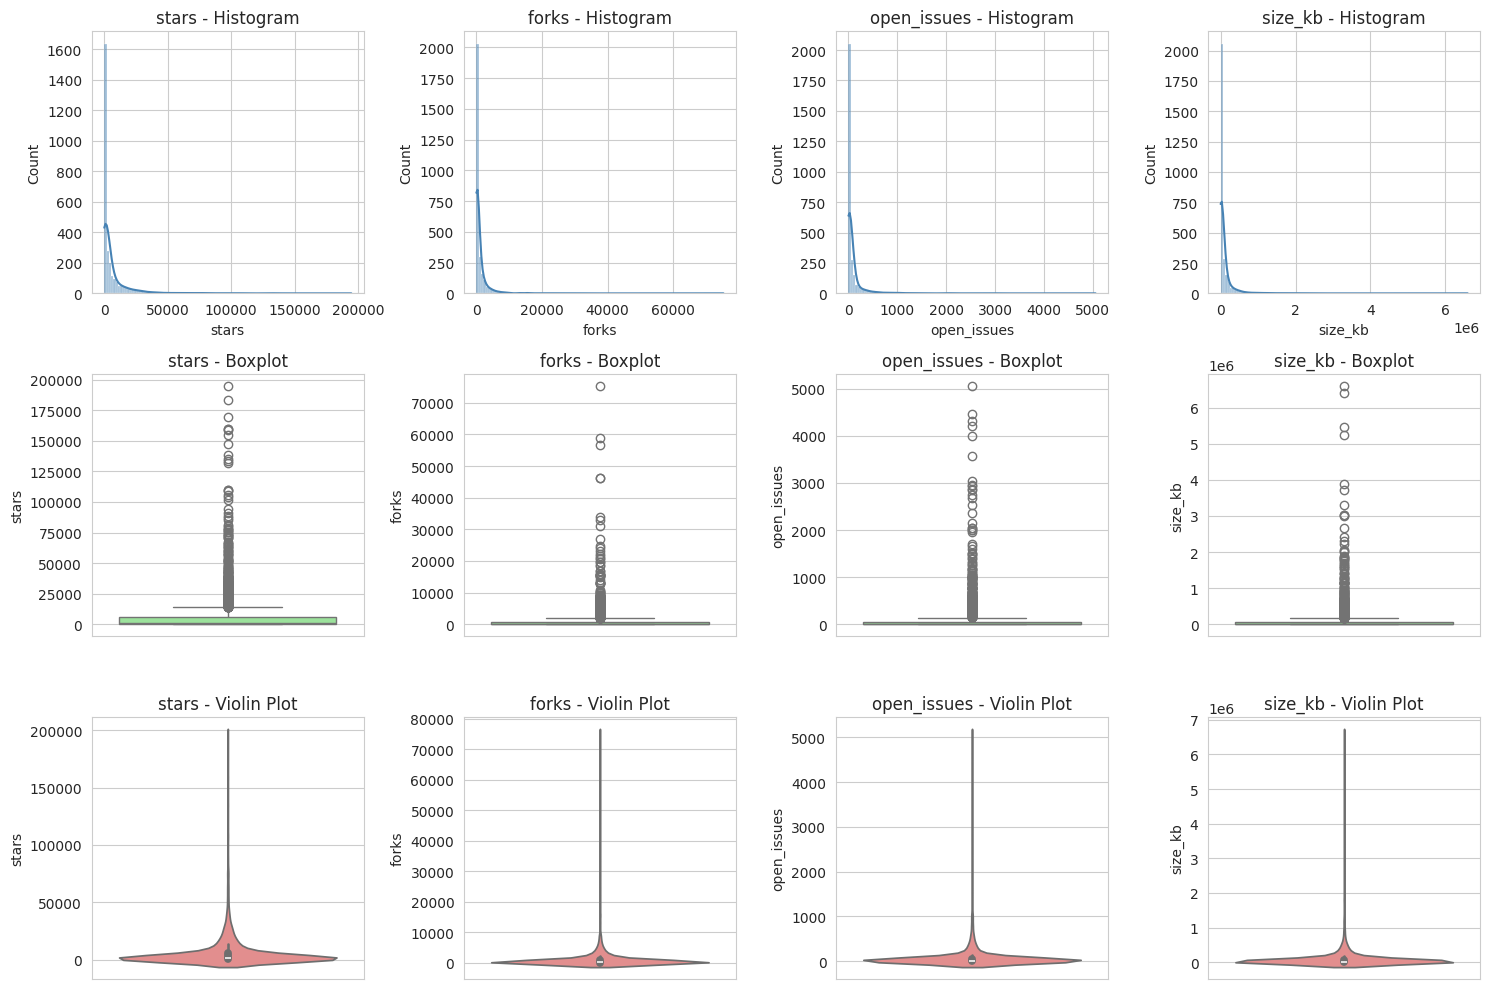

In [ ]:
# Distribution of key numeric variables: histogram+KDE, boxplot, and violin plot together
num_cols = ["stars", "forks", "open_issues", "size_kb"]

fig, axes = plt.subplots(3, 4, figsize=(15, 10))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color="steelblue")
    axes[0, i].set_title(f"{col} - Histogram")

    sns.boxplot(y=df[col], ax=axes[1, i], color="lightgreen")
    axes[1, i].set_title(f"{col} - Boxplot")

    sns.violinplot(y=df[col], ax=axes[2, i], color="lightcoral")
    axes[2, i].set_title(f"{col} - Violin Plot")

plt.tight_layout()
plt.show()

**Observation:** All four variables are heavily right-skewed — most repositories have small values, with a long tail of a few extremely popular repositories (like TensorFlow). This will need a log transformation before clustering.

In [ ]:
# Outlier detection using the IQR method (outliers are NOT removed)
outlier_summary = []

for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({"Column": col, "Outlier Count": len(outliers),
                             "Outlier %": round(len(outliers) / len(df) * 100, 2)})

pd.DataFrame(outlier_summary)

,Column,Outlier Count,Outlier %
0,stars,382,13.39
1,forks,382,13.39
2,open_issues,373,13.07
3,size_kb,364,12.76


**Observation:** A meaningful share of repositories are statistical outliers in each column. These are not errors — they are genuinely the most popular/active AI repositories, so they are kept (not removed) since they carry real signal for clustering.

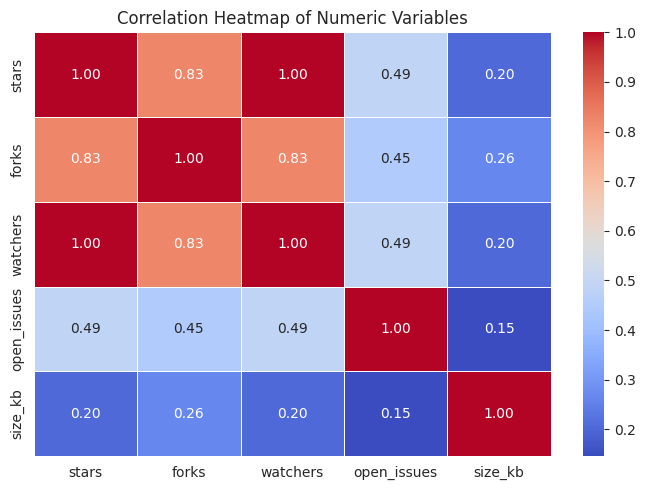

In [ ]:
# Correlation heatmap for numeric variables (used to check for redundant features)
corr_cols = ["stars", "forks", "watchers", "open_issues", "size_kb"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

**Observation:** `stars` and `watchers` are perfectly correlated (1.00) — they are identical in this dataset, so `watchers` is redundant and will be excluded from clustering. `forks` correlates strongly with `stars` (~0.83) but not perfectly, so it still adds unique information.

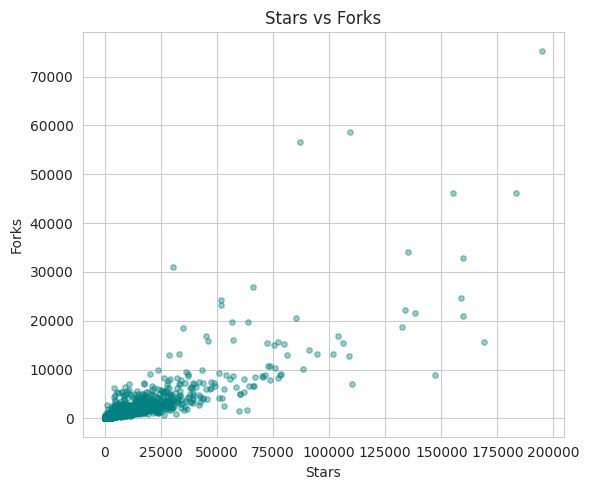

In [ ]:
# Stars vs Forks (the strongest relationship, used to sanity-check clustering features)
plt.figure(figsize=(6, 5))
plt.scatter(df["stars"], df["forks"], alpha=0.4, color="teal", s=15)
plt.title("Stars vs Forks")
plt.xlabel("Stars")
plt.ylabel("Forks")
plt.tight_layout()
plt.show()

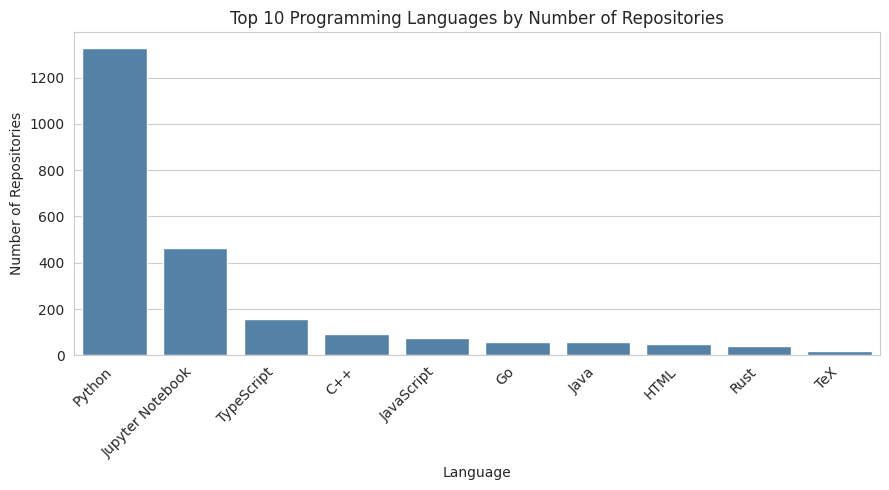

In [ ]:
# Top 10 programming languages (quick categorical context)
top_languages = df["language"].value_counts().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_languages.index, y=top_languages.values, color="steelblue")
plt.title("Top 10 Programming Languages by Number of Repositories")
plt.xlabel("Language")
plt.ylabel("Number of Repositories")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation:** Python and Jupyter Notebook dominate the AI repository landscape, as expected for this domain. This is useful context but language is not used as a clustering feature since the focus here is on numeric popularity/activity metrics.

In [ ]:
# Skewness of key numeric variables (justifies the log transform used later)
skew_df = df[num_cols].skew().sort_values(ascending=False).rename("Skewness").to_frame()
skew_df

,Skewness
forks,10.500827
size_kb,9.886446
open_issues,8.244187
stars,5.686577


**Observation:** All four features have skewness well above 1, confirming heavy right-skew. This is addressed with a log transformation in the preprocessing section below.

## 6. Data Preprocessing

Based on the EDA above, we now prepare the data for clustering.

### 6.1 Feature Selection for Clustering

**Selected features:** `stars`, `forks`, `open_issues`, `size_kb`

**Reasoning:**
- `stars` → overall popularity/adoption.
- `forks` → how much the community actively builds on the project (kept despite correlation with stars because it's strong, not perfect — 0.83, not 1.00).
- `open_issues` → maintenance activity and community engagement.
- `size_kb` → scale/complexity of the codebase.

**Features excluded, and why:**
- `watchers` → excluded, perfectly correlated (1.00) with `stars` — pure duplicate information.
- `contributors`, `commits_last_4w`, `commits_last_52w` → excluded, missing for 82–99% of rows.
- `language`, `license`, text columns → not numeric, kept only for context/interpretation, not clustering.

In [ ]:
# Create the feature matrix for clustering
features = ["stars", "forks", "open_issues", "size_kb"]
X = df[features].copy()

# Check for missing values, then fill as a safety step (none expected here)
print("Missing values in selected features:")
print(X.isnull().sum())
X = X.fillna(X.median())

Missing values in selected features:
stars          0
forks          0
open_issues    0
size_kb        0
dtype: int64


### 6.2 Log Transformation

Since all four features are heavily right-skewed, we apply `log1p` (`log(1 + x)`, safely handles zeros) to make the distributions more symmetric and suitable for distance-based clustering.

In [ ]:
# Apply log1p transformation and compare skewness before vs after
X_log = np.log1p(X)

skew_compare = pd.DataFrame({"Before Log": X.skew(), "After Log": X_log.skew()})
skew_compare.round(3)

,Before Log,After Log
stars,5.687,0.240
forks,10.501,0.173
open_issues,8.244,0.315
size_kb,9.886,-0.475


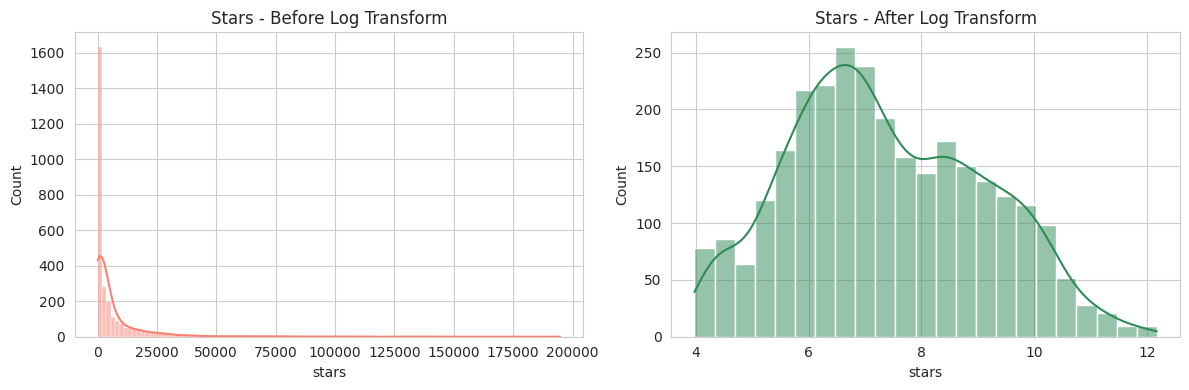

In [ ]:
# Visualize the effect of log transformation on 'stars' as an example
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X["stars"], kde=True, ax=axes[0], color="salmon")
axes[0].set_title("Stars - Before Log Transform")
sns.histplot(X_log["stars"], kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Stars - After Log Transform")
plt.tight_layout()
plt.show()

**Observation:** Skewness dropped sharply for every feature after the log transform, and the `stars` distribution is now much closer to symmetric. This transformed data is what we scale and cluster on.

### 6.3 Feature Scaling

Clustering algorithms measure distance between points. Since `size_kb` has much larger raw values than `open_issues`, it would dominate the distance calculation unless every feature is on the same scale. `StandardScaler` gives every feature mean 0 and standard deviation 1.

In [ ]:
# Scale the log-transformed features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Confirm scaling worked
print("Mean of each scaled feature:", np.round(X_scaled.mean(axis=0), 2))
print("Std of each scaled feature :", np.round(X_scaled.std(axis=0), 2))

Mean of each scaled feature: [ 0.  0. -0.  0.]
Std of each scaled feature : [1. 1. 1. 1.]


# Clustering Analysis

This is the core of the project. We now determine the optimal number of clusters, apply three different clustering algorithms (K-Means, DBSCAN, Agglomerative Clustering), evaluate each one in depth, visualize the results, and interpret what the clusters actually mean.

## 7. K-Means Clustering

### 7.1 Finding the Optimal Number of Clusters (K)

We use two standard methods together — the **Elbow Method** (based on inertia) and the **Silhouette Method** (based on cluster separation) — instead of guessing K.

In [ ]:
# Elbow Method: calculate inertia for K = 2 to 10
k_values = range(2, 11)
inertia_list = []

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertia_list.append(kmeans_temp.inertia_)

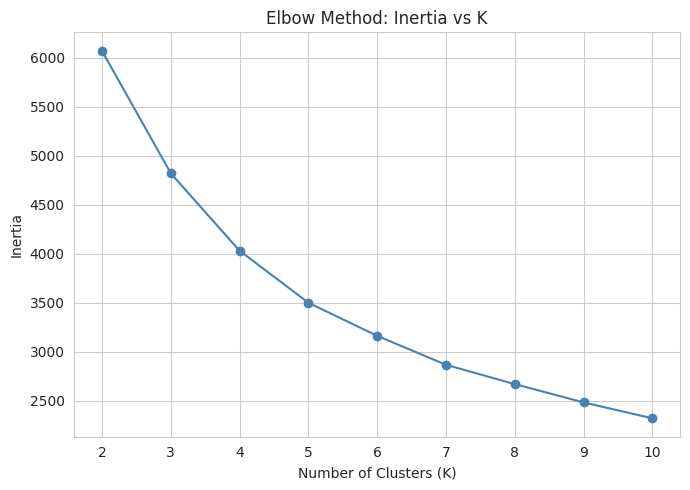

In [ ]:
# Plot Elbow curve
plt.figure(figsize=(7, 5))
plt.plot(list(k_values), inertia_list, marker="o", color="steelblue")
plt.title("Elbow Method: Inertia vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

In [ ]:
# Silhouette Method: calculate silhouette score for K = 2 to 10
silhouette_list = []

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    silhouette_list.append(silhouette_score(X_scaled, labels_temp))

best_k = list(k_values)[np.argmax(silhouette_list)]
print("Best K based on highest silhouette score:", best_k)

Best K based on highest silhouette score: 2


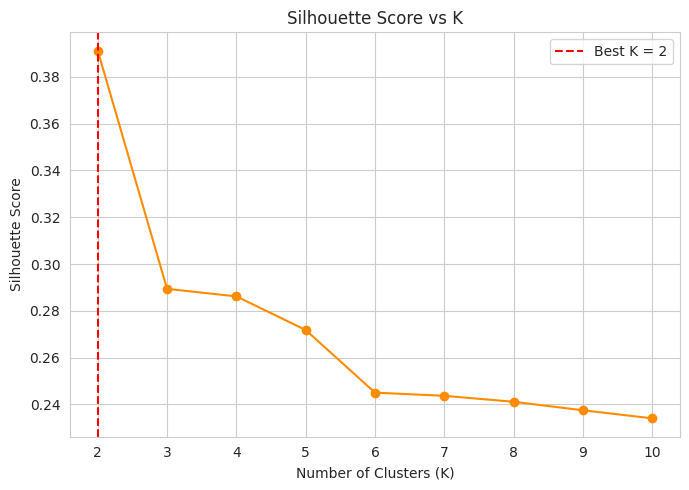

In [ ]:
# Plot Silhouette score vs K
plt.figure(figsize=(7, 5))
plt.plot(list(k_values), silhouette_list, marker="o", color="darkorange")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** The elbow curve bends gradually without one sharp \"elbow\", which is common for real-world data. The silhouette score is clearer — it is highest at **K = 2** and drops steadily as K increases, meaning the data naturally separates into two well-defined groups rather than several smaller ones. **K = 2** is selected for the final K-Means model.

### 7.2 Final K-Means Model

In [ ]:
# Fit K-Means with the selected best K
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

print("Cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

Cluster sizes:
0    1698
1    1155
Name: count, dtype: int64


### 7.3 K-Means Evaluation

- **Silhouette Score** (higher is better, -1 to 1) — how well-separated the clusters are.
- **Davies-Bouldin Index** (lower is better) — average similarity between each cluster and its closest neighbor.
- **Calinski-Harabasz Index** (higher is better) — ratio of between-cluster to within-cluster variance.

In [ ]:
# K-Means evaluation metrics
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_ch = calinski_harabasz_score(X_scaled, kmeans_labels)

print("K-Means Silhouette Score   :", round(kmeans_silhouette, 4))
print("K-Means Davies-Bouldin     :", round(kmeans_db, 4))
print("K-Means Calinski-Harabasz  :", round(kmeans_ch, 2))

K-Means Silhouette Score   : 0.3912
K-Means Davies-Bouldin     : 0.9693
K-Means Calinski-Harabasz  : 2507.65


### 7.4 Silhouette Plot for K-Means

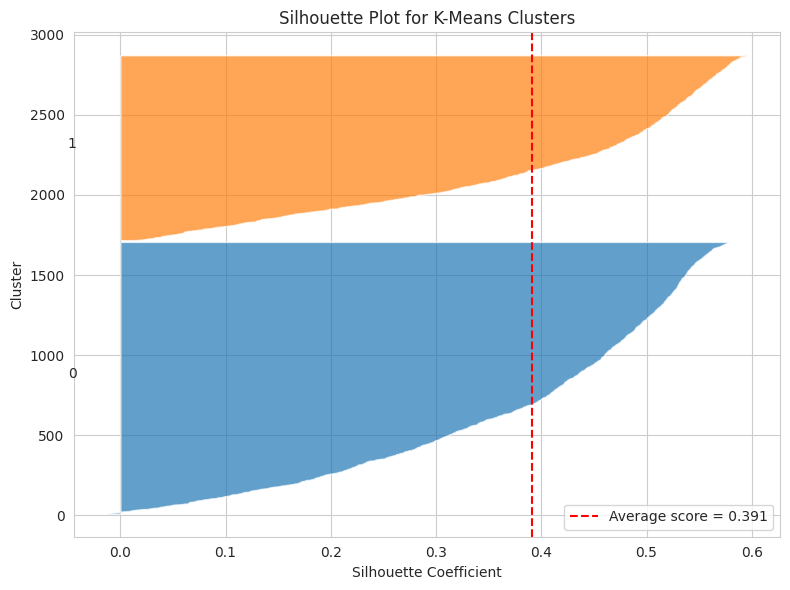

In [ ]:
# Silhouette plot showing individual silhouette values per cluster
sample_silhouette_values = silhouette_samples(X_scaled, kmeans_labels)

plt.figure(figsize=(8, 6))
y_lower = 10

for i in range(best_k):
    cluster_values = sample_silhouette_values[kmeans_labels == i]
    cluster_values.sort()
    size_cluster_i = cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_values, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(kmeans_silhouette, color="red", linestyle="--", label=f"Average score = {kmeans_silhouette:.3f}")
plt.title("Silhouette Plot for K-Means Clusters")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** Both clusters have most silhouette values above the average line and mostly positive, meaning points are, on average, closer to their own cluster than to the other one — a reasonably well-separated result.

## 8. DBSCAN Clustering

Unlike K-Means, DBSCAN does not require the number of clusters in advance. It needs two parameters instead:
- **eps** — maximum distance between two points for them to be considered neighbors.
- **min_samples** — minimum number of points needed to form a dense region (a cluster).

We test a small, reasonable set of combinations rather than assuming one is correct.

In [ ]:
# Test a small set of reasonable eps / min_samples combinations
dbscan_results = []

for eps in [0.3, 0.5, 0.7, 0.9]:
    for min_samples in [5, 10, 15]:
        db_temp = DBSCAN(eps=eps, min_samples=min_samples)
        labels_temp = db_temp.fit_predict(X_scaled)

        n_clusters_temp = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
        n_noise_temp = list(labels_temp).count(-1)

        if n_clusters_temp >= 2:
            mask_temp = labels_temp != -1
            sil_temp = silhouette_score(X_scaled[mask_temp], labels_temp[mask_temp])
        else:
            sil_temp = None

        dbscan_results.append({
            "eps": eps, "min_samples": min_samples, "clusters": n_clusters_temp,
            "noise_points": n_noise_temp,
            "noise_%": round(n_noise_temp / len(labels_temp) * 100, 2),
            "silhouette": sil_temp
        })

pd.DataFrame(dbscan_results)

,eps,min_samples,clusters,noise_points,noise_%,silhouette
0,0.3,5,42,1263,44.27,-0.328419
1,0.3,10,11,2262,79.28,0.047511
2,0.3,15,5,2708,94.92,0.561799
3,0.5,5,3,146,5.12,0.371774
4,0.5,10,1,280,9.81,NaN
5,0.5,15,1,488,17.10,NaN
6,0.7,5,1,32,1.12,NaN
7,0.7,10,2,52,1.82,0.398134
8,0.7,15,1,75,2.63,NaN
9,0.9,5,1,8,0.28,NaN


**Observation:** Very small `eps` creates too many tiny clusters and lots of noise; very large `eps` merges everything into one cluster. **eps = 0.7, min_samples = 10** gives the best balance — 2 meaningful clusters with very low noise (under 2%) and a solid silhouette score. This combination is selected for the final DBSCAN model.

In [ ]:
# Fit final DBSCAN model with the selected parameters
dbscan = DBSCAN(eps=0.7, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print("Number of clusters found:", n_clusters_dbscan)
print("Number of noise points  :", n_noise_dbscan)
print("Noise percentage        :", round(n_noise_dbscan / len(dbscan_labels) * 100, 2), "%")

Number of clusters found: 2
Number of noise points  : 52
Noise percentage        : 1.82 %


### 8.1 DBSCAN Evaluation

In [ ]:
# Evaluate DBSCAN (excluding noise points, and only if valid)
if n_clusters_dbscan >= 2:
    mask = dbscan_labels != -1
    dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    dbscan_db = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
    dbscan_ch = calinski_harabasz_score(X_scaled[mask], dbscan_labels[mask])
else:
    dbscan_silhouette = dbscan_db = dbscan_ch = None
    print("DBSCAN did not find a valid number of clusters (need at least 2) to compute these metrics.")

print("DBSCAN Silhouette Score   :", round(dbscan_silhouette, 4) if dbscan_silhouette is not None else "N/A")
print("DBSCAN Davies-Bouldin     :", round(dbscan_db, 4) if dbscan_db is not None else "N/A")
print("DBSCAN Calinski-Harabasz  :", round(dbscan_ch, 2) if dbscan_ch is not None else "N/A")

DBSCAN Silhouette Score   : 0.3981
DBSCAN Davies-Bouldin     : 0.512
DBSCAN Calinski-Harabasz  : 53.91


**Observation:** DBSCAN found 2 clusters with very few noise points. Its silhouette score is close to K-Means, its Davies-Bouldin score is better (lower), but its Calinski-Harabasz score is much lower — this trade-off is discussed in the final comparison.

## 9. Agglomerative Clustering

A hierarchical, bottom-up method: it starts with every point as its own cluster and repeatedly merges the closest pairs until the desired number of clusters (K) is reached. We use the same K as K-Means for a fair comparison.

In [ ]:
# Fit Agglomerative Clustering using the same K as K-Means
agglo = AgglomerativeClustering(n_clusters=best_k)
agglo_labels = agglo.fit_predict(X_scaled)

df["Agglomerative_Cluster"] = agglo_labels

print("Cluster sizes:")
print(pd.Series(agglo_labels).value_counts().sort_index())

Cluster sizes:
0    1986
1     867
Name: count, dtype: int64


In [ ]:
# Agglomerative Clustering evaluation metrics
agglo_silhouette = silhouette_score(X_scaled, agglo_labels)
agglo_db = davies_bouldin_score(X_scaled, agglo_labels)
agglo_ch = calinski_harabasz_score(X_scaled, agglo_labels)

print("Agglomerative Silhouette Score   :", round(agglo_silhouette, 4))
print("Agglomerative Davies-Bouldin     :", round(agglo_db, 4))
print("Agglomerative Calinski-Harabasz  :", round(agglo_ch, 2))

Agglomerative Silhouette Score   : 0.3772
Agglomerative Davies-Bouldin     : 0.938
Agglomerative Calinski-Harabasz  : 2180.34


### 9.1 Dendrogram

Since Agglomerative Clustering is hierarchical, we can visualize the merging process. A random sample is used to keep the dendrogram readable.

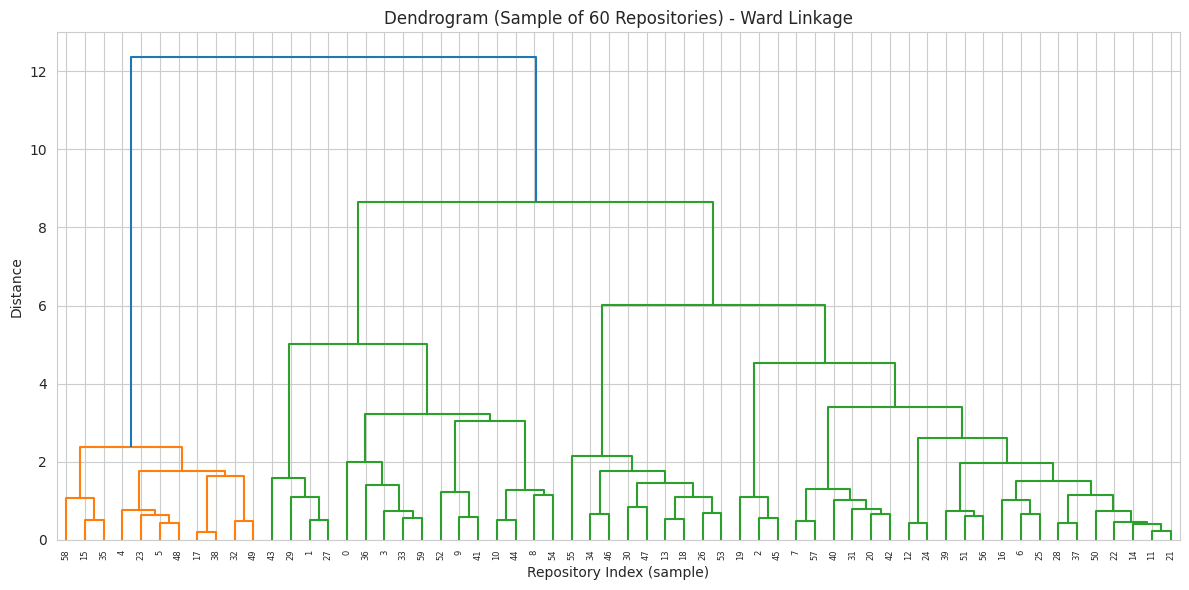

In [ ]:
# Dendrogram using a sample of the scaled data (for readability)
np.random.seed(42)
sample_idx = np.random.choice(X_scaled.shape[0], size=60, replace=False)
X_sample = X_scaled[sample_idx]

linked = linkage(X_sample, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Dendrogram (Sample of 60 Repositories) - Ward Linkage")
plt.xlabel("Repository Index (sample)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

**Observation:** The dendrogram shows repositories progressively merging into larger groups as the distance threshold increases. Cutting the tree near the tallest vertical gaps supports splitting the data into a small number of clusters, consistent with the K chosen via Elbow/Silhouette.

## 10. Cluster Profiling (K-Means)

We describe what each K-Means cluster actually represents, using real calculated statistics.

In [ ]:
# Build a cluster profile table for the final K-Means clusters
cluster_profile = df.groupby("KMeans_Cluster")[["stars", "forks", "open_issues", "size_kb"]].agg(
    Count=("stars", "count"),
    Mean_Stars=("stars", "mean"), Median_Stars=("stars", "median"),
    Mean_Forks=("forks", "mean"), Median_Forks=("forks", "median"),
    Mean_Open_Issues=("open_issues", "mean"), Median_Open_Issues=("open_issues", "median"),
    Mean_Size_KB=("size_kb", "mean"), Median_Size_KB=("size_kb", "median"),
)

cluster_profile.round(1)

,Count,Mean_Stars,Median_Stars,Mean_Forks,Median_Forks,Mean_Open_Issues,Median_Open_Issues,Mean_Size_KB,Median_Size_KB
KMeans_Cluster,,,,,,,,,
0,1698,847.4,545.0,126.5,74.0,11.9,4.0,48159.9,6336.0
1,1155,15375.5,8124.0,2598.2,1271.0,221.0,77.0,191291.9,51165.0


In [ ]:
# Print a simple, data-driven interpretation of each cluster
for cluster_id in sorted(df["KMeans_Cluster"].unique()):
    row = cluster_profile.loc[cluster_id]
    print(f"Cluster {cluster_id}: {int(row['Count'])} repositories")
    print(f"  Mean stars: {row['Mean_Stars']:.0f}  |  Mean forks: {row['Mean_Forks']:.0f}")
    print(f"  Mean open issues: {row['Mean_Open_Issues']:.0f}  |  Mean size (KB): {row['Mean_Size_KB']:.0f}")
    print()

Cluster 0: 1698 repositories
  Mean stars: 847  |  Mean forks: 127
  Mean open issues: 12  |  Mean size (KB): 48160

Cluster 1: 1155 repositories
  Mean stars: 15375  |  Mean forks: 2598
  Mean open issues: 221  |  Mean size (KB): 191292



**Interpretation:**
- **Cluster 0** has clearly lower mean/median stars, forks, and size — the **typical / lower-popularity repositories**, the majority of the dataset.
- **Cluster 1** has much higher mean/median stars, forks, and size — the **high-popularity, larger, more actively engaged repositories** (e.g. TensorFlow, AutoGPT, Ollama).

## 11. PCA Visualization

To visualize clusters that exist in 4-dimensional feature space, we reduce the data to 2 dimensions using PCA and plot each clustering result separately.

In [ ]:
# Reduce scaled features to 2 dimensions using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance by PCA 1:", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("Explained variance by PCA 2:", round(pca.explained_variance_ratio_[1] * 100, 2), "%")
print("Total explained variance   :", round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

Explained variance by PCA 1: 67.4 %
Explained variance by PCA 2: 20.12 %
Total explained variance   : 87.52 %


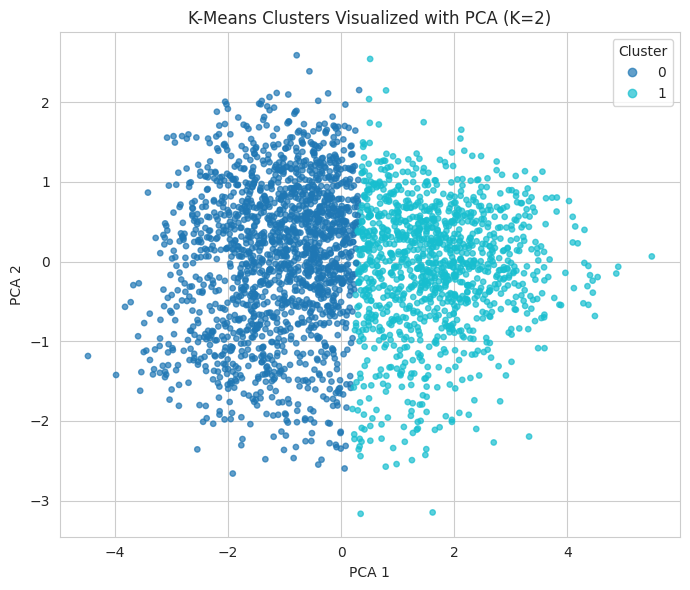

In [ ]:
# PCA visualization for K-Means clusters
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="tab10", s=15, alpha=0.7)
plt.title(f"K-Means Clusters Visualized with PCA (K={best_k})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

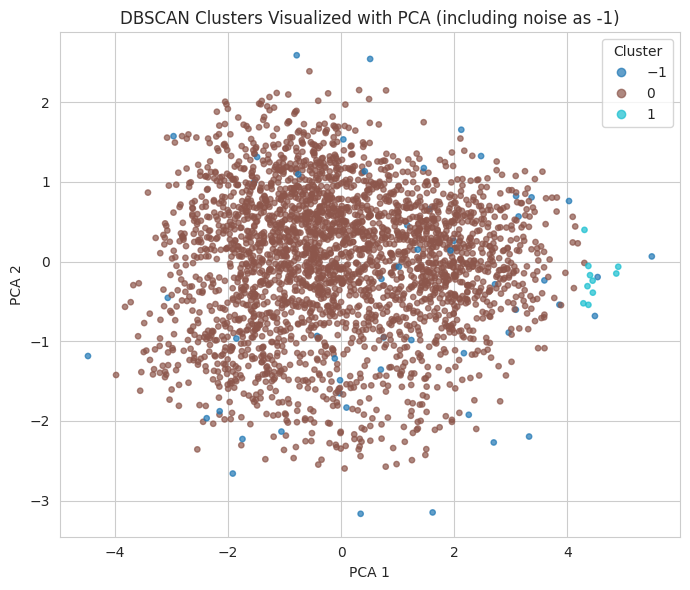

In [ ]:
# PCA visualization for DBSCAN clusters
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap="tab10", s=15, alpha=0.7)
plt.title("DBSCAN Clusters Visualized with PCA (including noise as -1)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

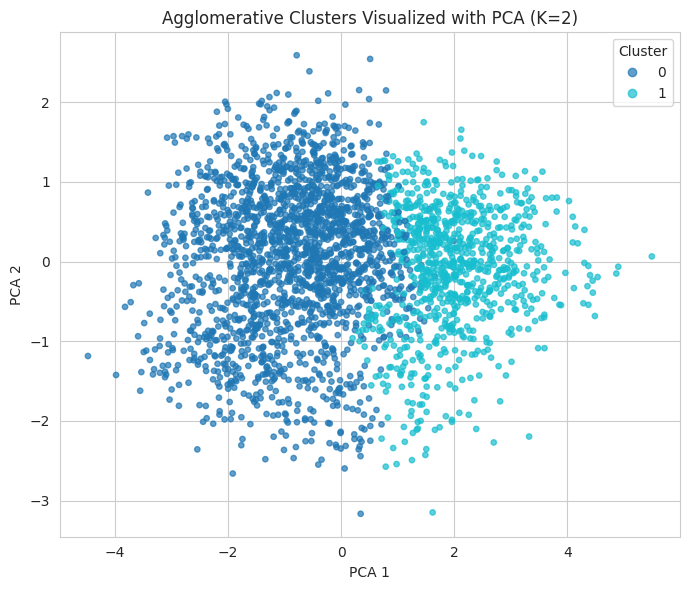

In [ ]:
# PCA visualization for Agglomerative Clustering
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap="tab10", s=15, alpha=0.7)
plt.title(f"Agglomerative Clusters Visualized with PCA (K={best_k})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

**Observation:** All three methods largely agree on the same broad split between \"popular/large\" and \"typical\" repositories, visible as two separated regions along PCA 1. DBSCAN additionally shows a small number of noise points (label -1) that don't fit cleanly into either dense region.

## 12. Final Model Comparison

Evaluation metrics from all three models, computed directly from the results above (no hard-coded values).

In [ ]:
# Build the final comparison table from actual computed results
comparison_table = pd.DataFrame({
    "Model": ["K-Means", "DBSCAN", "Agglomerative"],
    "Clusters": [best_k, n_clusters_dbscan, best_k],
    "Noise Points": [0, n_noise_dbscan, 0],
    "Silhouette": [
        round(kmeans_silhouette, 4),
        round(dbscan_silhouette, 4) if dbscan_silhouette is not None else np.nan,
        round(agglo_silhouette, 4)
    ],
    "Davies-Bouldin": [
        round(kmeans_db, 4),
        round(dbscan_db, 4) if dbscan_db is not None else np.nan,
        round(agglo_db, 4)
    ],
    "Calinski-Harabasz": [
        round(kmeans_ch, 2),
        round(dbscan_ch, 2) if dbscan_ch is not None else np.nan,
        round(agglo_ch, 2)
    ]
})

comparison_table

,Model,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,2,0,0.3912,0.9693,2507.65
1,DBSCAN,2,52,0.3981,0.5120,53.91
2,Agglomerative,2,0,0.3772,0.9380,2180.34


In [ ]:
# Identify the strongest model based on silhouette score (higher is better)
best_model_row = comparison_table.loc[comparison_table["Silhouette"].idxmax()]
print("Highest silhouette score belongs to:", best_model_row["Model"])
print(best_model_row)

Highest silhouette score belongs to: DBSCAN
Model                DBSCAN
Clusters                  2
Noise Points             52
Silhouette           0.3981
Davies-Bouldin        0.512
Calinski-Harabasz     53.91
Name: 1, dtype: object


**Observation:** K-Means and Agglomerative Clustering perform very similarly, with K-Means slightly ahead on silhouette score and Calinski-Harabasz. DBSCAN has the best Davies-Bouldin score and a comparable silhouette score, but a much lower Calinski-Harabasz score, and leaves a few points unclustered as noise. No single model wins on every metric — the choice depends on whether every repository must be assigned to a cluster (favoring K-Means/Agglomerative) or whether flagging a few as noise is acceptable (favoring DBSCAN).

## Final Analysis and Conclusion

**1. What the dataset contains:**
2,853 GitHub repositories related to AI, with metadata such as stars, forks, watchers, open issues, repository size, programming language, license, and (partially available) contributor/commit activity.

**2. What was discovered during EDA:**
`stars`, `forks`, `open_issues`, `size_kb` are all heavily right-skewed, dominated by a handful of very popular repositories (e.g. TensorFlow, AutoGPT, Ollama). `watchers` is perfectly correlated (1.00) with `stars`, and `contributors`/commit-activity columns are missing for 82–99% of rows.

**3. Features selected for clustering:**
`stars`, `forks`, `open_issues`, `size_kb` — fully populated, numeric, and each capturing a different, non-redundant aspect of a repository.

**4. Why preprocessing was required:**
The features had very different scales and heavy skew, both of which distort distance-based clustering. `log1p` reduced the skew, and `StandardScaler` then put every feature on a comparable scale.

**5. Which K was selected and why:**
K = 2 — the silhouette score was clearly highest at K = 2 and decreased steadily for larger K, showing the data naturally splits into two dominant groups.

**6. What K-Means discovered:**
Two clusters — a large group of lower-popularity, smaller repositories, and a smaller group of high-popularity, larger, more actively engaged repositories — with a silhouette score of about 0.39.

**7. What DBSCAN discovered:**
With eps = 0.7, min_samples = 10, DBSCAN also found 2 dense clusters, with under 2% of repositories left as noise, and a silhouette score close to K-Means'.

**8. What Agglomerative Clustering discovered:**
Using the same K = 2, it produced a similar two-group split, with metrics close to (slightly below) K-Means.

**9. Which model performed best:**
K-Means had the best overall balance of metrics (highest silhouette and Calinski-Harabasz, second-best Davies-Bouldin) while assigning every repository to a cluster. DBSCAN is a reasonable alternative when flagging a small number of repositories as noise is acceptable.

**10. What the clusters mean:**
GitHub AI repositories split into **"mainstream/typical" projects** and **"breakout/highly popular" projects** — driven mainly by scale of adoption (stars, forks) rather than by programming language or license.

**11. Limitations:**
- Only 4 numeric features were used; `contributors` and commit-activity data were too incomplete to use.
- Clustering was based purely on numeric popularity/activity metrics, not repository content or code quality.
- The two-cluster solution is simple and interpretable but coarse — it doesn't separate, e.g., large-but-unpopular repos from small-but-highly-active ones.

**12. Possible future improvements:**
- Re-run once more repositories have complete `contributors`/commit-activity data.
- Explore text-based features from `description`/`topics` to complement the numeric clusters.
- Try a higher K with more granular metrics if finer-grained segments are needed.